In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
df = pd.read_csv("ddos_dataset.csv")

print(df.shape)

df.head()

(431371, 78)


,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,17,48,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
1,17,2,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
2,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
3,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,1480,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
4,17,1,2,0,2896.0,0.0,1448.0,1448.0,1448.0,0.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS


In [ ]:
main_types = ["Benign", "Syn", "UDP", "DNS"]

df_main = df[df["Label"].isin(main_types)]

df_main["Label"].value_counts()

Label
Benign    97831
Syn       49373
UDP       18090
Name: count, dtype: int64

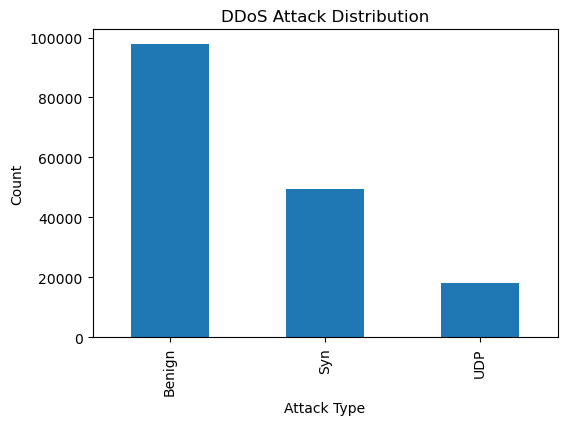

In [ ]:
plt.figure(figsize=(6,4))

df_main["Label"].value_counts().plot(kind="bar")

plt.title("DDoS Attack Distribution")
plt.xlabel("Attack Type")
plt.ylabel("Count")

plt.show()

In [ ]:
X = df_main.drop("Label", axis=1)
y = df_main["Label"]

X = X.select_dtypes(include=["number"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100)

model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.9992437762787744


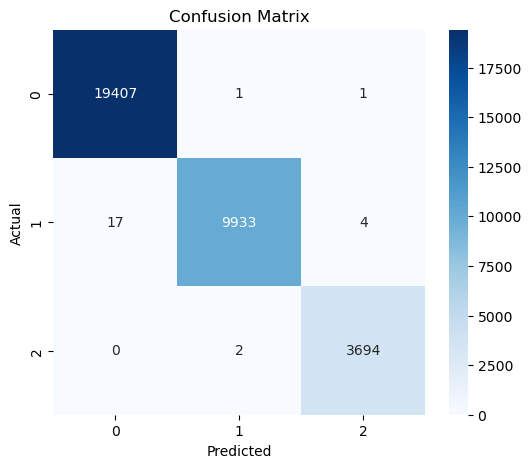

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
import joblib

joblib.dump(model, "ddos_model.pkl")

print("Model saved successfully")

Model saved successfully


import pandas as pd
import matplotlib.pyplot as plt

# Load Excel or CSV dataset
data = pd.read_excel("ddos_dataset.xlsx")   # or pd.read_csv("dataset.csv")

# Example: Attack type distribution
attack_counts = data['Label'].value_counts()

plt.figure()
attack_counts.plot(kind='bar')
plt.title("DDoS Attack Type Distribution")
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.show()



In [1]:
print(df['Label'].value_counts())

NameError: name 'df' is not defined

In [2]:
import pandas as pd

df = pd.read_csv("ddos_dataset.csv")

print(df.head())

   Protocol  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0        17             48                  2                       0   
1        17              2                  2                       0   
2        17              1                  2                       0   
3        17              1                  2                       0   
4        17              1                  2                       0   

   Fwd Packets Length Total  Bwd Packets Length Total  Fwd Packet Length Max  \
0                    2944.0                       0.0                 1472.0   
1                    2944.0                       0.0                 1472.0   
2                    2944.0                       0.0                 1472.0   
3                    2944.0                       0.0                 1472.0   
4                    2896.0                       0.0                 1448.0   

   Fwd Packet Length Min  Fwd Packet Length Mean  Fwd Packet Length Std  ...  \


In [3]:
X = df.drop('Label', axis=1)
y = df['Label']

In [4]:
print(df.columns)

Index(['Protocol', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Fwd Packets Length Total',
       'Bwd Packets Length Total', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Count', 'RST Fla

In [5]:
import pandas as pd

df = pd.read_csv("ddos_dataset.csv")
df.columns = df.columns.str.strip()

print(df.head())

   Protocol  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0        17             48                  2                       0   
1        17              2                  2                       0   
2        17              1                  2                       0   
3        17              1                  2                       0   
4        17              1                  2                       0   

   Fwd Packets Length Total  Bwd Packets Length Total  Fwd Packet Length Max  \
0                    2944.0                       0.0                 1472.0   
1                    2944.0                       0.0                 1472.0   
2                    2944.0                       0.0                 1472.0   
3                    2944.0                       0.0                 1472.0   
4                    2896.0                       0.0                 1448.0   

   Fwd Packet Length Min  Fwd Packet Length Mean  Fwd Packet Length Std  ...  \


In [6]:
X = df.drop('Label', axis=1)
y = df['Label']

In [7]:
print(X.shape)
print(y.shape)

(431371, 77)
(431371,)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(345096, 77)
(86275, 77)


In [9]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200, random_state=42)

model.fit(X_train, y_train)

print("Model training completed")

Model training completed


In [10]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy * 100)

Accuracy: 92.79165459287164


In [11]:
import numpy as np

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

In [12]:
print(X.isnull().sum().sum())

0


In [13]:
from sklearn.ensemble import ExtraTreesClassifier

model = ExtraTreesClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model trained")

Model trained


In [14]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred)*100)

Accuracy: 92.51926977687627


In [15]:
rom sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

SyntaxError: invalid syntax (4233439661.py, line 1)

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
print(df['Label'].value_counts())

Label
DrDoS_NTP        121368
TFTP              98917
Benign            97831
Syn               49373
UDP               18090
DrDoS_UDP         10420
UDP-lag            8872
MSSQL              8523
DrDoS_MSSQL        6212
DrDoS_DNS          3669
DrDoS_SNMP         2717
LDAP               1906
DrDoS_LDAP         1440
Portmap             685
NetBIOS             644
DrDoS_NetBIOS       598
UDPLag               55
WebDDoS              51
Name: count, dtype: int64


In [21]:
df_filtered = df[df['Label'].isin(['Benign', 'Syn', 'UDP', 'DrDoS_NTP', 'DrDoS_DNS', 'DrDoS_UDP'])]

In [22]:
df_filtered = df.copy()

df_filtered['Label'] = df_filtered['Label'].replace({
    'DrDoS_NTP': 'DrDoS',
    'DrDoS_DNS': 'DrDoS',
    'DrDoS_UDP': 'DrDoS',
    'DrDoS_MSSQL': 'DrDoS',
    'DrDoS_SNMP': 'DrDoS',
    'DrDoS_LDAP': 'DrDoS',
    'DrDoS_NetBIOS': 'DrDoS',
    'WebDDoS': 'DrDoS',
    'TFTP': 'UDP',
    'UDP-lag': 'UDP',
    'UDPLag': 'UDP'
})

In [23]:
df_filtered = df.copy()

df_filtered['Label'] = df_filtered['Label'].replace({
    'DrDoS_NTP': 'DrDoS',
    'DrDoS_DNS': 'DrDoS',
    'DrDoS_UDP': 'DrDoS',
    'DrDoS_MSSQL': 'DrDoS',
    'DrDoS_SNMP': 'DrDoS',
    'DrDoS_LDAP': 'DrDoS',
    'DrDoS_NetBIOS': 'DrDoS',
    'WebDDoS': 'DrDoS',
    'TFTP': 'UDP',
    'UDP-lag': 'UDP',
    'UDPLag': 'UDP'
})

df_filtered = df_filtered[df_filtered['Label'].isin(['Benign','DrDoS','UDP','Syn'])]

In [24]:
print(df_filtered['Label'].value_counts())

Label
DrDoS     146475
UDP       125934
Benign     97831
Syn        49373
Name: count, dtype: int64


In [25]:
print(df_filtered.head())

   Protocol  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0        17             48                  2                       0   
1        17              2                  2                       0   
2        17              1                  2                       0   
3        17              1                  2                       0   
4        17              1                  2                       0   

   Fwd Packets Length Total  Bwd Packets Length Total  Fwd Packet Length Max  \
0                    2944.0                       0.0                 1472.0   
1                    2944.0                       0.0                 1472.0   
2                    2944.0                       0.0                 1472.0   
3                    2944.0                       0.0                 1472.0   
4                    2896.0                       0.0                 1448.0   

   Fwd Packet Length Min  Fwd Packet Length Mean  Fwd Packet Length Std  ...  \


In [29]:
X = df_filtered.drop('Label', axis=1)
y = df_filtered['Label']

print(X.shape)
print(y.shape)

(419613, 77)
(419613,)


In [30]:
print(y.value_counts())

Label
DrDoS     146475
UDP       125934
Benign     97831
Syn        49373
Name: count, dtype: int64


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [33]:
import joblib

joblib.dump(model, "ddos_model.pkl")

print("Model saved successfully")

Model saved successfully


In [34]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred)*100)

Accuracy: 96.98414022377656


In [35]:
import joblib

joblib.dump(model, "ddos_model.pkl")

print("Model saved successfully")

Model saved successfully


In [5]:
import pandas as pd
import numpy as np

In [6]:
df = pd.read_csv("ddos_dataset.csv")

In [7]:
df.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,17,48,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
1,17,2,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
2,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
3,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,1480,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS
4,17,1,2,0,2896.0,0.0,1448.0,1448.0,1448.0,0.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DrDoS_DNS


In [8]:
print(df.columns)

Index(['Protocol', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Fwd Packets Length Total',
       'Bwd Packets Length Total', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Count', 'RST Fla

In [9]:
df_filtered=df.copy()

In [10]:
features = [
"Flow Duration",
"Total Fwd Packets",
"Total Backward Packets",
"Fwd Packets Length Total",
"Bwd Packets Length Total",
"Flow Bytes/s",
"Flow Packets/s"
]

X = df_filtered[features]
y = df_filtered["Label"]

In [11]:
X.shape

(431371, 7)

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
df_filtered = df.copy()

In [14]:
features = [
"Flow Duration",
"Total Fwd Packets",
"Total Backward Packets",
"Fwd Packets Length Total",
"Bwd Packets Length Total",
"Flow Bytes/s",
"Flow Packets/s"
]

X = df_filtered[features]
y = df_filtered["Label"]

In [15]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200)

In [1]:
import pandas as pd
import numpy as np


In [3]:
import joblib

model = joblib.load("ddos_model.pkl")

print(model.classes_)

['Benign' 'DrDoS_DNS' 'DrDoS_LDAP' 'DrDoS_MSSQL' 'DrDoS_NTP'
 'DrDoS_NetBIOS' 'DrDoS_SNMP' 'DrDoS_UDP' 'LDAP' 'MSSQL' 'NetBIOS'
 'Portmap' 'Syn' 'TFTP' 'UDP' 'UDP-lag' 'UDPLag' 'WebDDoS']


In [4]:
import joblib

joblib.dump(model, "ddos_model.pkl")

print("Model saved successfully")

Model saved successfully


In [1]:
import pandas as pd

df = pd.read_csv("ddos_dataset.csv")

# Keep only 4 attack types
df = df[df['Label'].isin(['Benign','UDP','Syn','DrDoS'])]

In [5]:
df = df[df['Label'].isin(['Benign','ICMP','UDP','Syn'])]

In [9]:
df['Label'] = df['Label'].replace({'DrDoS_NTP':'DrDoS'})

In [10]:
df = df[df['Label'].isin(['Benign','Syn','UDP','DrDoS'])]

In [11]:
features = [
"Flow Duration",
"Total Fwd Packets",
"Total Backward Packets",
"Fwd Packets Length Total",
"Bwd Packets Length Total",
"Flow Bytes/s",
"Flow Packets/s"
]

X = df[features]
y = df['Label']

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import joblib

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = RandomForestClassifier(n_estimators=200,random_state=42)
model.fit(X_train,y_train)

joblib.dump(model,"ddos_model.pkl")

['ddos_model.pkl']

In [12]:
print(model.classes_)

['Benign' 'Syn' 'UDP']


In [13]:
print(df['Label'].unique())

['Benign' 'Syn' 'UDP']


In [14]:
print(df['Label'].value_counts())

Label
Benign    97831
Syn       49373
UDP       18090
Name: count, dtype: int64


In [15]:
df['Label'] = df['Label'].replace({
'DrDoS_NTP':'DrDoS',
'DrDoS_DNS':'DrDoS',
'DrDoS_SNMP':'DrDoS',
'DrDoS_LDAP':'DrDoS',
'DrDoS_MSSQL':'DrDoS',
'DrDoS_NetBIOS':'DrDoS',
'DrDoS_UDP':'DrDoS'
})

In [16]:
df = df[df['Label'].isin(['Benign','Syn','UDP','DrDoS'])]

In [17]:
print(df['Label'].value_counts())

Label
Benign    97831
Syn       49373
UDP       18090
Name: count, dtype: int64


In [19]:
import pandas as pd

df = pd.read_csv("ddos_dataset.csv")

In [20]:
print(df['Label'].unique())

['DrDoS_DNS' 'Benign' 'DrDoS_LDAP' 'NetBIOS' 'LDAP' 'DrDoS_MSSQL' 'MSSQL'
 'DrDoS_NetBIOS' 'DrDoS_NTP' 'Portmap' 'DrDoS_SNMP' 'Syn' 'TFTP'
 'DrDoS_UDP' 'UDP' 'UDP-lag' 'WebDDoS' 'UDPLag']


In [22]:
# Convert all DrDoS_* to DrDoS
df.loc[df['Label'].str.contains('DrDoS', case=False), 'Label'] = 'DrDoS'

# Convert all UDP variants to UDP
df.loc[df['Label'].str.contains('UDP', case=False), 'Label'] = 'UDP'

In [24]:
df = df[df['Label'].isin(['Benign','Syn','UDP','DrDoS'])]

In [25]:
print(df['Label'].value_counts())

Label
DrDoS     146424
Benign     97831
Syn        49373
UDP        27017
Name: count, dtype: int64


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import joblib

features = [
"Flow Duration",
"Total Fwd Packets",
"Total Backward Packets",
"Fwd Packets Length Total",
"Bwd Packets Length Total",
"Flow Bytes/s",
"Flow Packets/s"
]

X = df[features]
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

joblib.dump(model, "ddos_model.pkl")

['ddos_model.pkl']

In [27]:
print(model.classes_)

['Benign' 'DrDoS' 'Syn' 'UDP']
